Loading FBXW7...
Loading MYC...
Loading NICD...


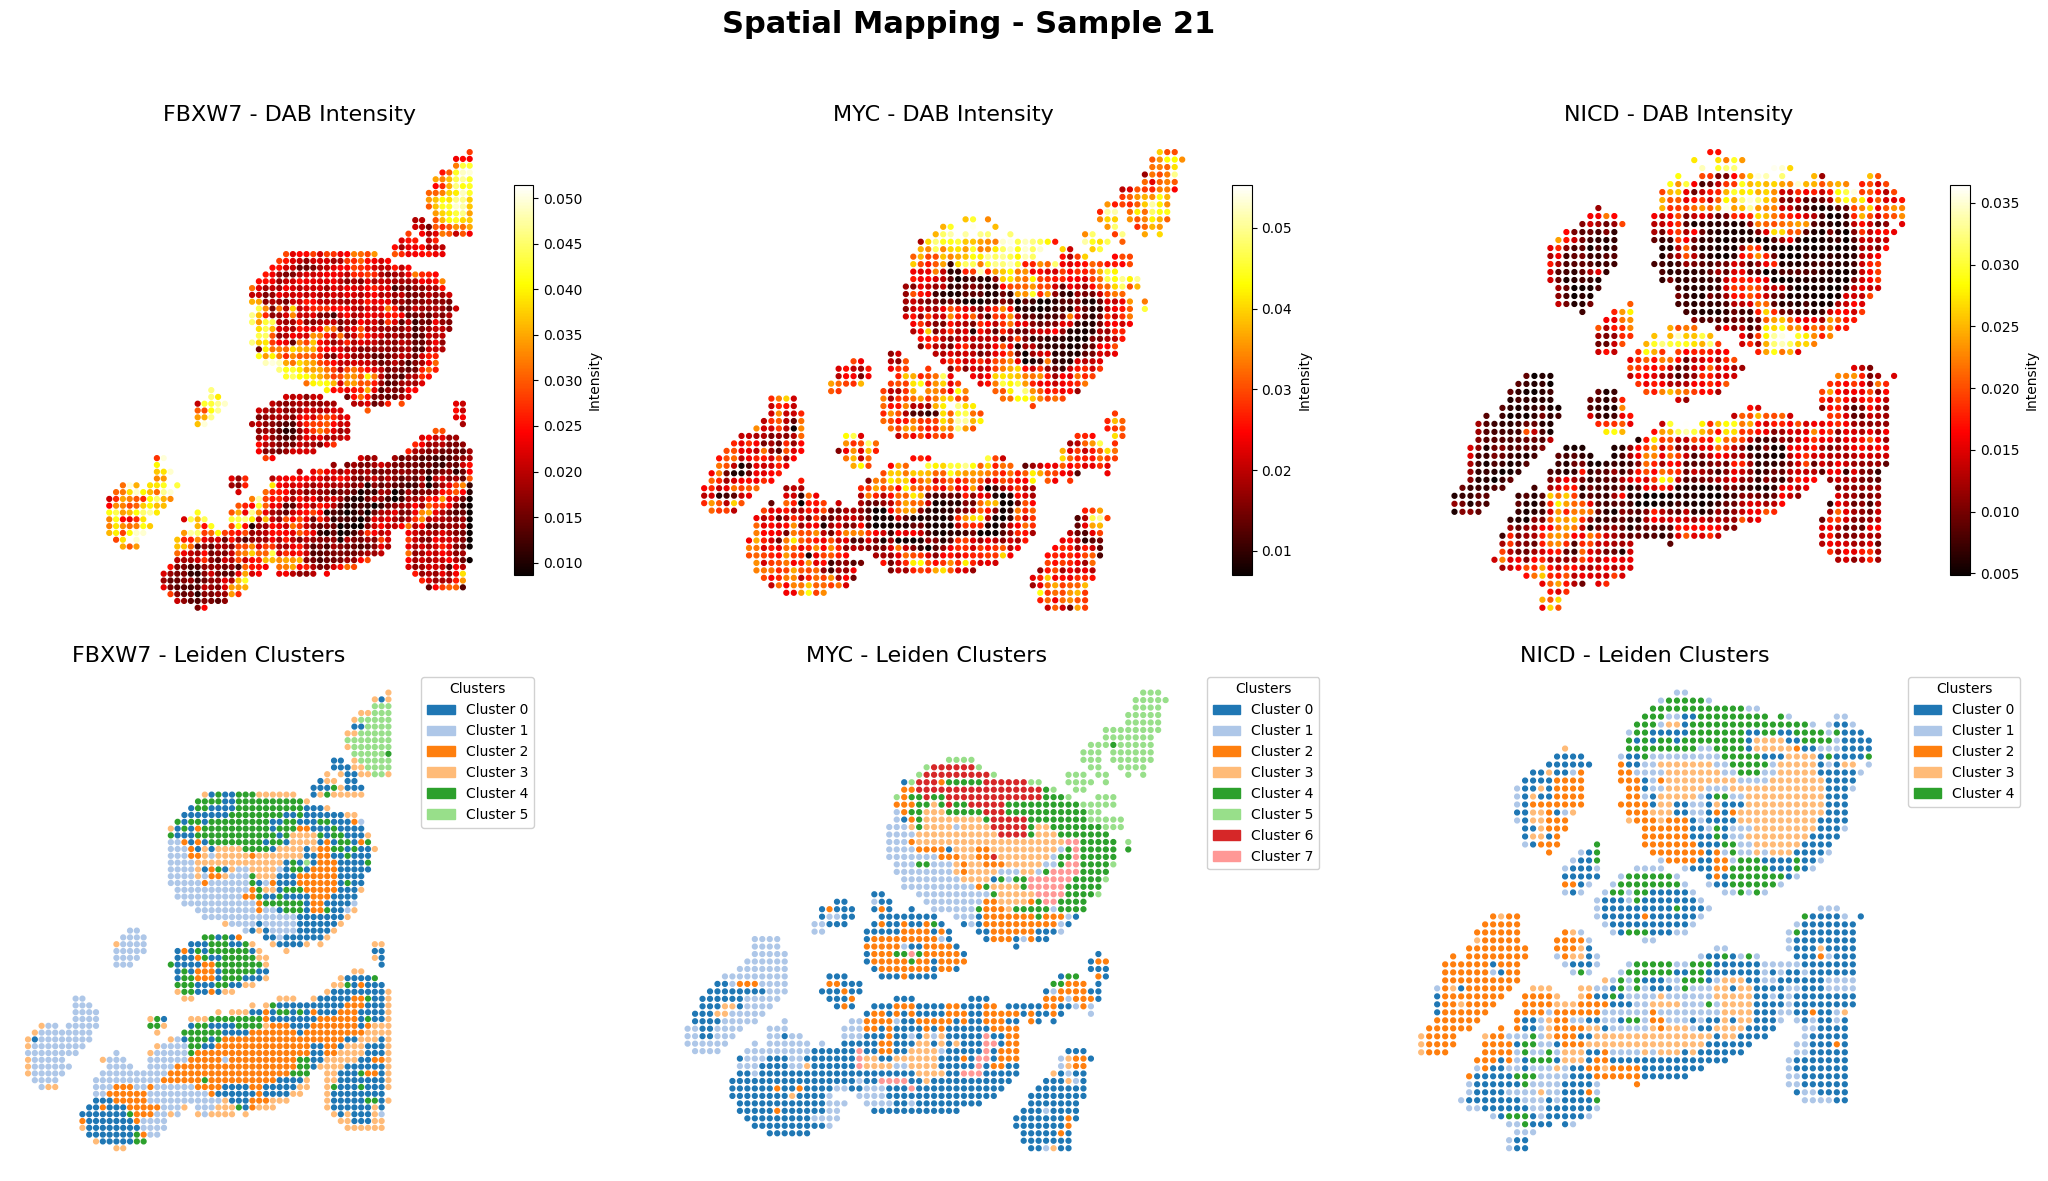

Saved plot to: /Users/lollija/phd/fbxw7/plots/spatial_maps_sample_21.png


In [10]:
import gc
import glob
import os
from pathlib import Path
import sys

import anndata as ad
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if (Path.cwd() / "scripts" / "config_utils.py").exists():
    sys.path.insert(0, str(Path.cwd() / "scripts"))
elif (Path.cwd() / "config_utils.py").exists():
    sys.path.insert(0, str(Path.cwd()))

from config_utils import get_markers, load_config, resolve_path

CONFIG_PATH = Path("config/default.yaml")
if not CONFIG_PATH.exists():
    CONFIG_PATH = Path("../config/default.yaml")

config = load_config(CONFIG_PATH)
RESULTS_DIR = resolve_path(config, "results_per_sample_dir")
PLOT_DIR = resolve_path(config, "plots_dir")
os.makedirs(PLOT_DIR, exist_ok=True)

MARKERS = get_markers(config)
SAMPLE_ID = "21"

ANNOTATION_COLORS = {
    "unannotated": "#d3d3d3",
    "not tumor": "#737373",
    "low": "#3182bd",
    "low to medium": "#9ecae1",
    "medium": "#fd8d3c",
    "medium to high": "#f03b20",
    "high": "#bd0026",
    "mixed": "#756bb1",
}


fig, axes = plt.subplots(nrows=2, ncols=len(MARKERS), figsize=(22, 12))
fig.suptitle(f"Spatial Mapping - Sample {SAMPLE_ID}", fontsize=22, fontweight="bold", y=0.98)

cmap_clusters = plt.colormaps.get_cmap("tab20")

for i, marker in enumerate(MARKERS):
    adata_path = os.path.join(RESULTS_DIR, f"adata_{SAMPLE_ID}_{marker}.h5ad")

    if not os.path.exists(adata_path):
        print(f"Missing: {adata_path}")
        axes[0, i].axis("off")
        axes[1, i].axis("off")
        axes[0, i].set_title(f"{marker} not found", color="red")
        continue

    print(f"Loading {marker}...")
    adata = ad.read_h5ad(adata_path)

    x = adata.obs["x"].values
    y = -adata.obs["y"].values

    dab = adata.obs["dab"].values
    p1, p99 = np.percentile(dab, [1, 99])

    sc1 = axes[0, i].scatter(x, y, c=np.clip(dab, p1, p99), cmap="hot", s=12, rasterized=True)
    axes[0, i].set_title(f"{marker} - DAB Intensity", fontsize=16)
    axes[0, i].set_aspect("equal")
    axes[0, i].axis("off")
    plt.colorbar(sc1, ax=axes[0, i], fraction=0.03, pad=0.04, label="Intensity")

    leiden_cat = adata.obs["leiden"].astype("category")
    categories = leiden_cat.cat.categories
    colors = [cmap_clusters(int(c) % 20) for c in categories]
    color_map = dict(zip(categories, colors))
    c_mapped = [color_map[c] for c in leiden_cat]

    axes[1, i].scatter(x, y, c=c_mapped, s=12, rasterized=True)
    axes[1, i].set_title(f"{marker} - Leiden Clusters", fontsize=16)
    axes[1, i].set_aspect("equal")
    axes[1, i].axis("off")

    handles = [mpatches.Patch(color=color_map[c], label=f"Cluster {c}") for c in categories]
    ncol = 2 if len(categories) > 10 else 1
    axes[1, i].legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left",
                      fontsize=10, framealpha=0.9, title="Clusters", ncol=ncol)

plt.tight_layout(rect=[0, 0, 1, 0.95])
out_path = os.path.join(PLOT_DIR, f"spatial_maps_sample_{SAMPLE_ID}.png")
plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved plot to: {out_path}")


Loading FBXW7...
Loading MYC...
Loading NICD...


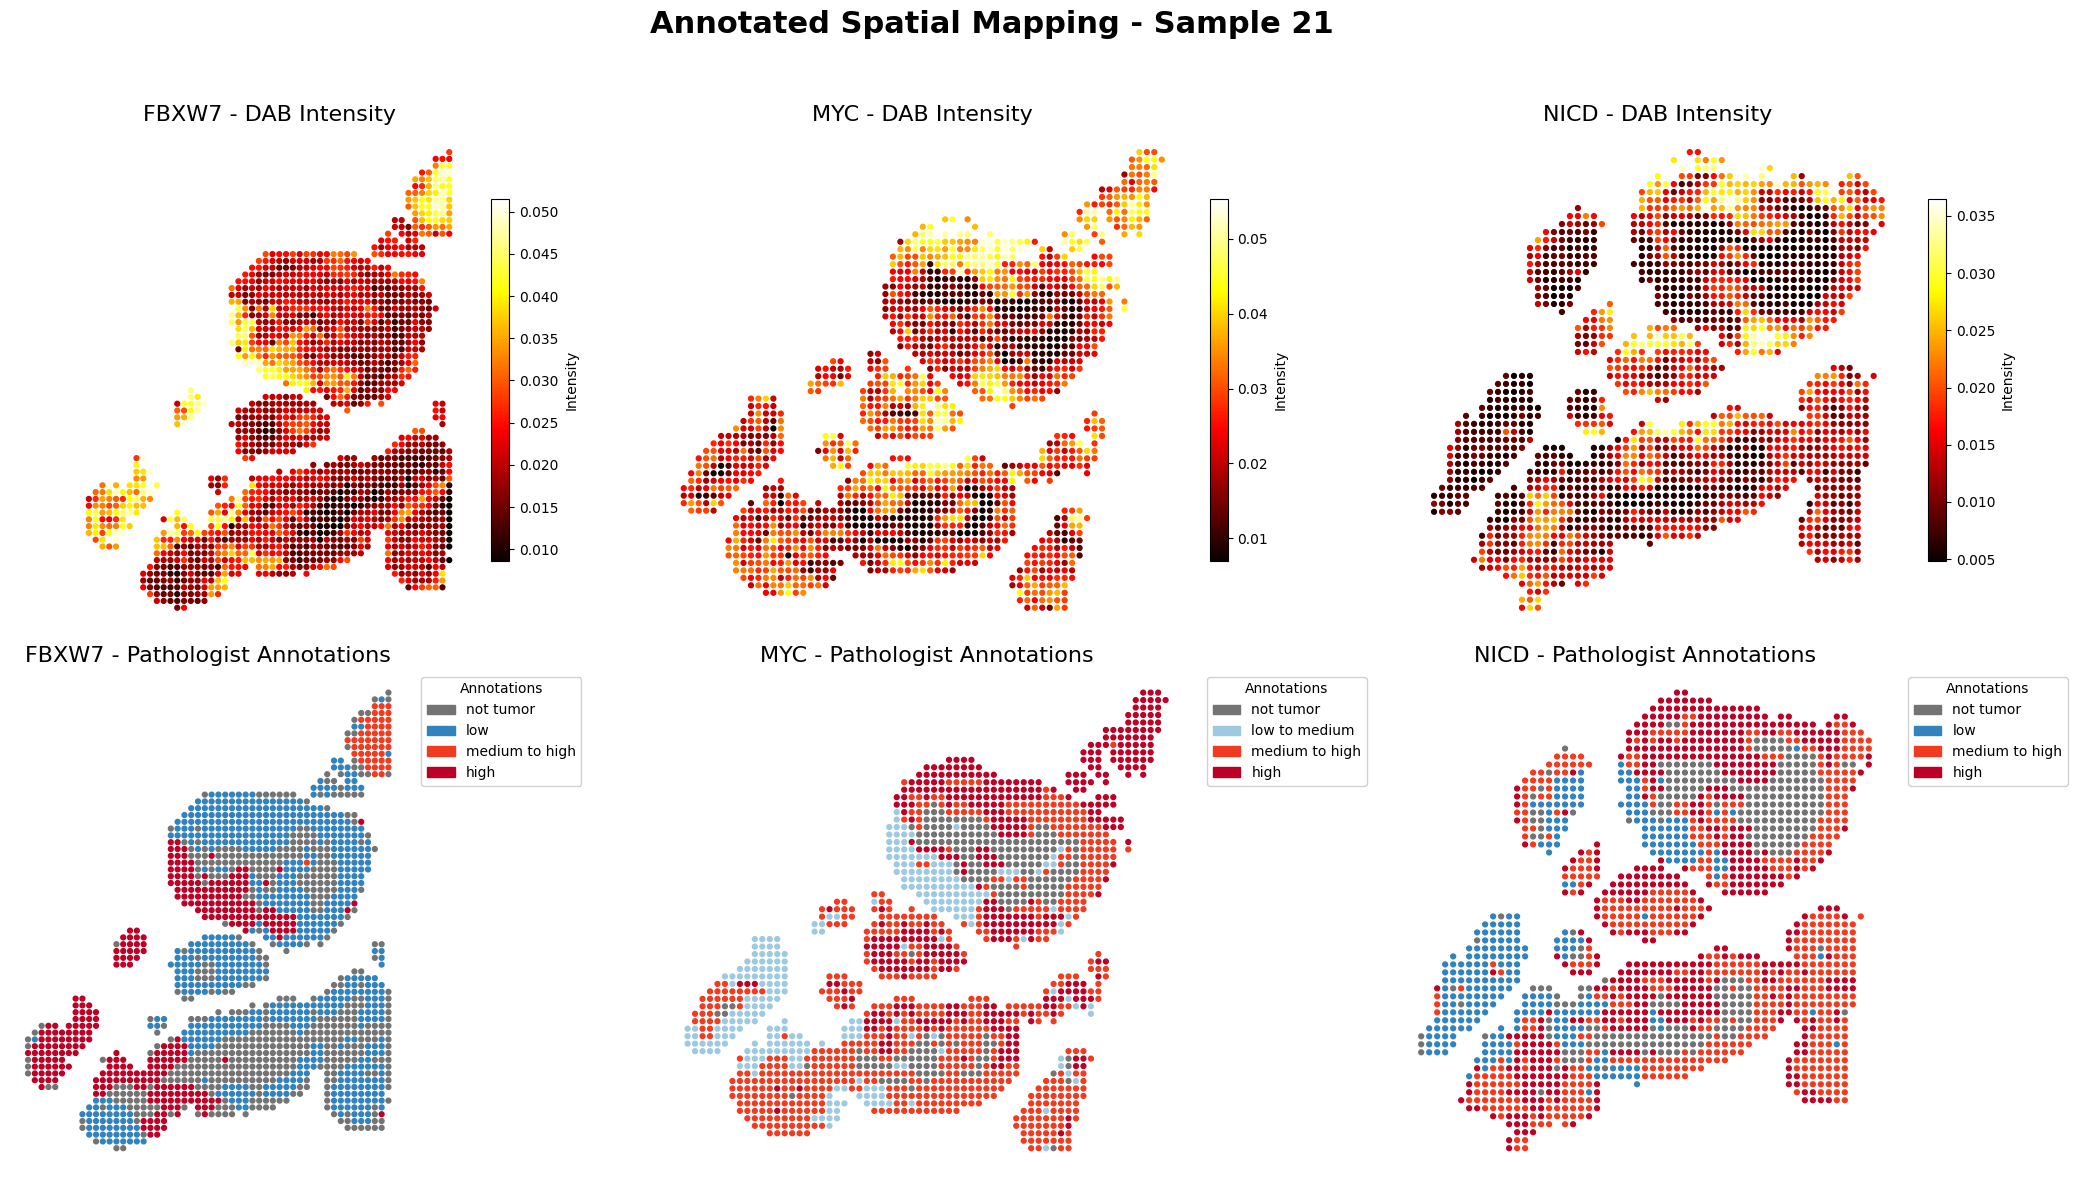

Saved plot to: /Users/lollija/phd/fbxw7/plots/spatial_maps_annotations_sample_21.png


In [11]:
import gc
import glob
import os
from pathlib import Path
import sys

import anndata as ad
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if (Path.cwd() / "scripts" / "config_utils.py").exists():
    sys.path.insert(0, str(Path.cwd() / "scripts"))
elif (Path.cwd() / "config_utils.py").exists():
    sys.path.insert(0, str(Path.cwd()))

from config_utils import get_markers, load_config, resolve_path

CONFIG_PATH = Path("config/default.yaml")
if not CONFIG_PATH.exists():
    CONFIG_PATH = Path("../config/default.yaml")

config = load_config(CONFIG_PATH)
RESULTS_DIR = resolve_path(config, "results_per_sample_dir")
PLOT_DIR = resolve_path(config, "plots_dir")
os.makedirs(PLOT_DIR, exist_ok=True)

MARKERS = get_markers(config)
SAMPLE_ID = "21"

ANNOTATION_COLORS = {
    "unannotated": "#d3d3d3",
    "not tumor": "#737373",
    "low": "#3182bd",
    "low to medium": "#9ecae1",
    "medium": "#fd8d3c",
    "medium to high": "#f03b20",
    "high": "#bd0026",
    "mixed": "#756bb1",
}


fig, axes = plt.subplots(nrows=2, ncols=len(MARKERS), figsize=(22, 12))
fig.suptitle(
    f"Annotated Spatial Mapping - Sample {SAMPLE_ID}",
    fontsize=22,
    fontweight="bold",
    y=0.98,
)

for i, marker in enumerate(MARKERS):
    adata_path = os.path.join(RESULTS_DIR, f"adata_{SAMPLE_ID}_{marker}.h5ad")

    if not os.path.exists(adata_path):
        print(f"Missing: {adata_path}")
        axes[0, i].axis("off")
        axes[1, i].axis("off")
        axes[0, i].set_title(f"{marker} not found", color="red")
        continue

    print(f"Loading {marker}...")
    adata = ad.read_h5ad(adata_path)

    x = adata.obs["x"].values
    y = -adata.obs["y"].values

    dab = adata.obs["dab"].values
    p1, p99 = np.percentile(dab, [1, 99])

    sc1 = axes[0, i].scatter(
        x,
        y,
        c=np.clip(dab, p1, p99),
        cmap="hot",
        s=12,
        rasterized=True,
    )
    axes[0, i].set_title(f"{marker} - DAB Intensity", fontsize=16)
    axes[0, i].set_aspect("equal")
    axes[0, i].axis("off")
    plt.colorbar(sc1, ax=axes[0, i], fraction=0.03, pad=0.04, label="Intensity")

    if "annotation" not in adata.obs.columns:
        print(f"No annotation column found for {marker}; showing all patches as unannotated.")
        annotations = np.array(["unannotated"] * adata.n_obs)
    else:
        annotations = adata.obs["annotation"].astype(str).values

    c_mapped = [ANNOTATION_COLORS.get(value, "#d3d3d3") for value in annotations]

    axes[1, i].scatter(x, y, c=c_mapped, s=12, rasterized=True)
    axes[1, i].set_title(f"{marker} - Pathologist Annotations", fontsize=16)
    axes[1, i].set_aspect("equal")
    axes[1, i].axis("off")

    present_annotations = set(annotations)
    ordered_annotations = [label for label in ANNOTATION_COLORS if label in present_annotations]

    handles = [
        mpatches.Patch(color=ANNOTATION_COLORS[label], label=label)
        for label in ordered_annotations
    ]
    if handles:
        axes[1, i].legend(
            handles=handles,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=10,
            framealpha=0.9,
            title="Annotations",
        )

plt.tight_layout(rect=[0, 0, 1, 0.95])
out_path = os.path.join(PLOT_DIR, f"spatial_maps_annotations_sample_{SAMPLE_ID}.png")
plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved plot to: {out_path}")


Processing per-sample annotations for FBXW7...
Patch Count Summary per Per-Sample Annotation (FBXW7):
sample             1   12   13    16    19     2    20   21    22    24   26     3   39    52    58     7  Total_Patches
annotation                                                                                                              
unannotated        0    0    0    43     0     0     0    0     0     0    0     0    0     0     0     0             43
not tumor          0   76   49     0     0  2285   193  528   543    76  182     0  303   885     0   539           5659
low                0    0  957     0   548     0   513  679     0     0    0     0  488     0     0  1970           5155
low to medium   1019    0    0  3221     0     0     0    0     0  1283  330     0    0  2113     0  1034           9000
medium             0    0    0     0   525     0  1449    0     0   335    0     0    0     0     0     0           2309
medium to high  1642  584    0  2503  1235     0   

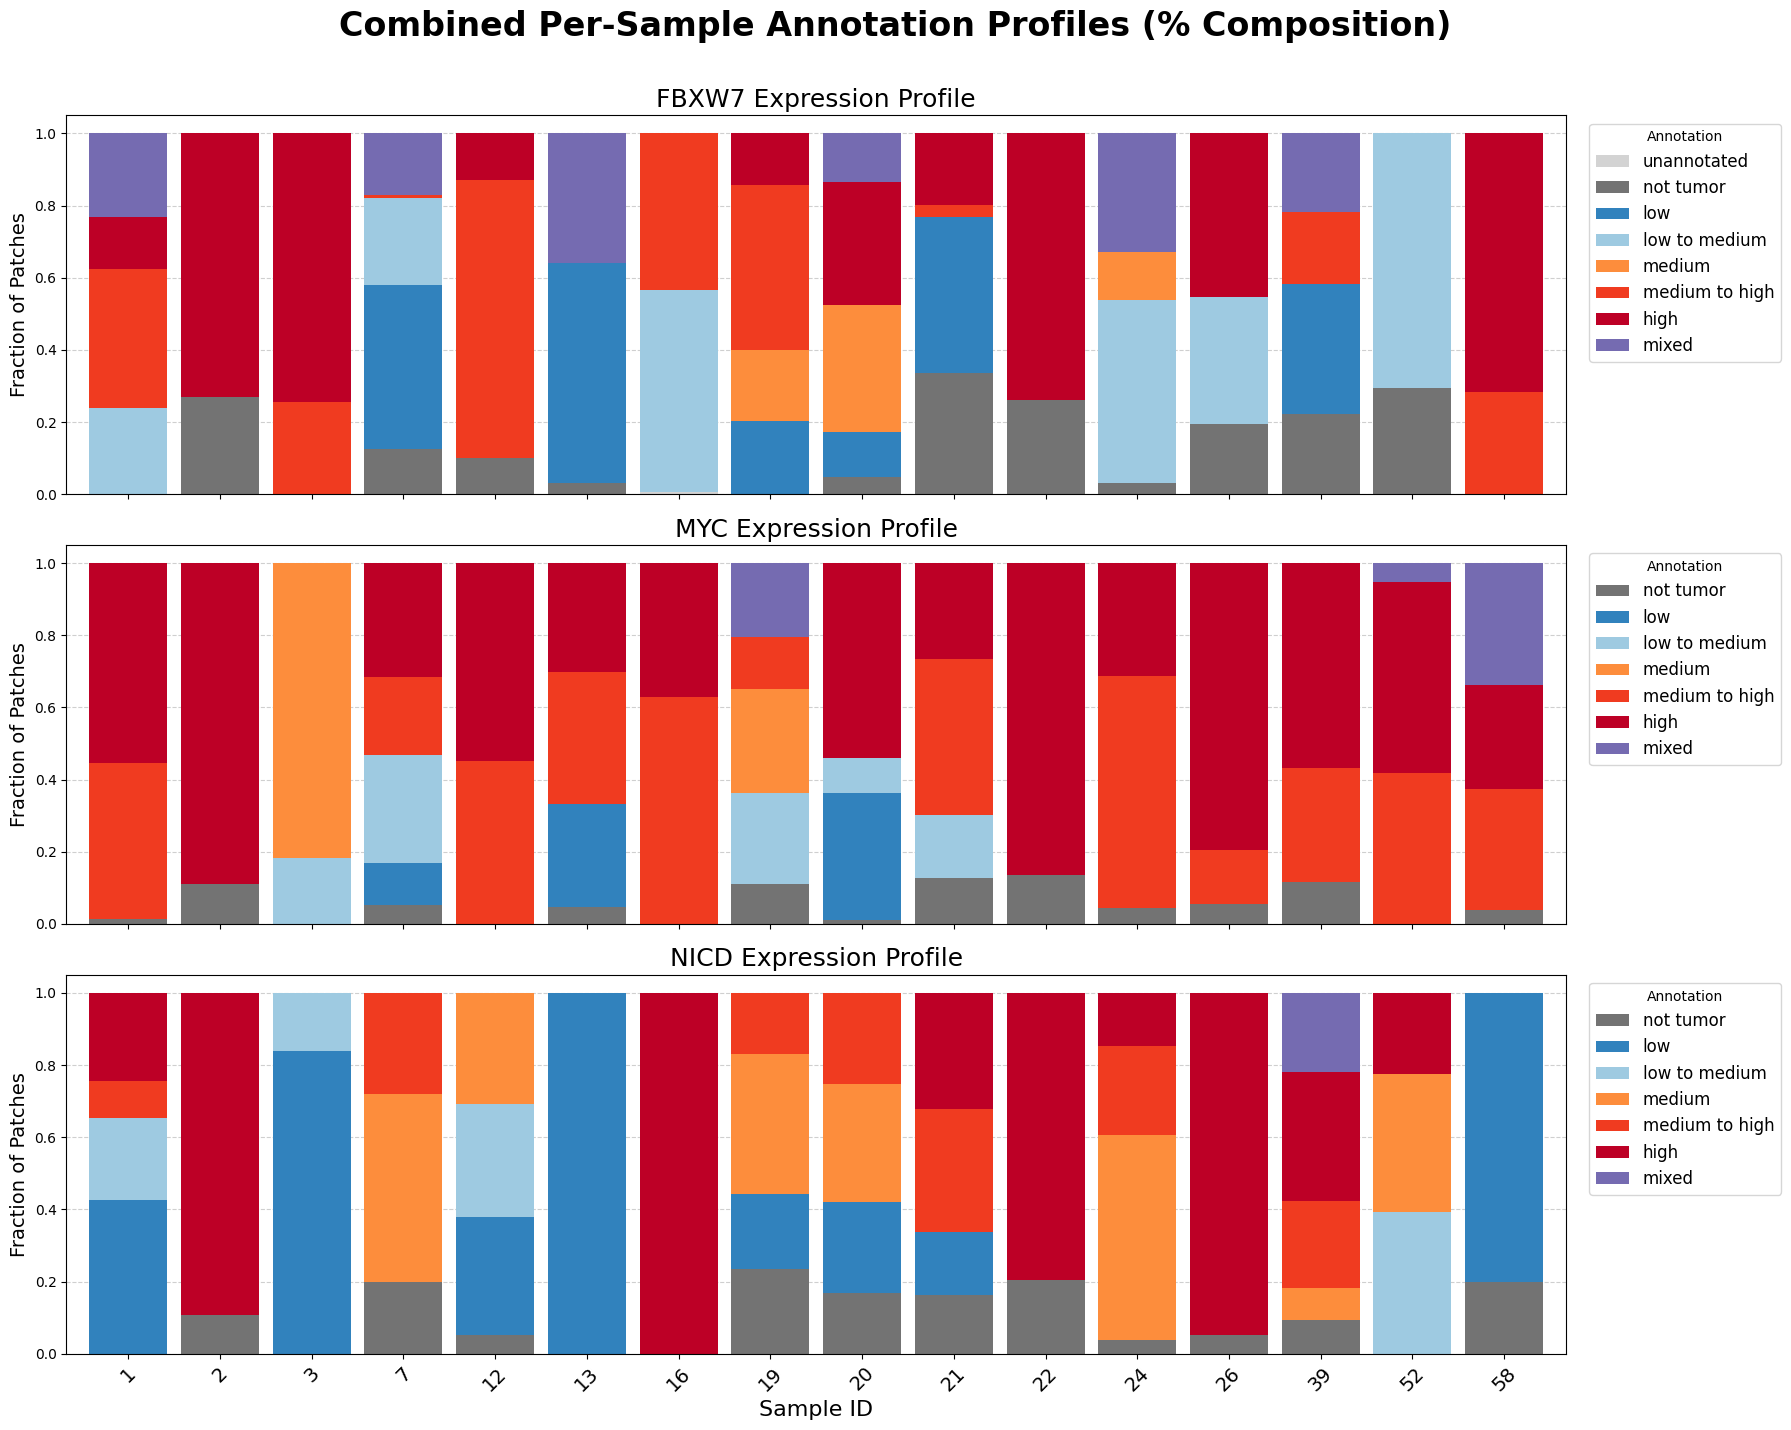

Master visualization saved to: /Users/lollija/phd/fbxw7/plots/combined_per_sample_annotation_profiles_relative.png


In [14]:
import gc
import glob
import os
from pathlib import Path
import sys

import anndata as ad
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if (Path.cwd() / "scripts" / "config_utils.py").exists():
    sys.path.insert(0, str(Path.cwd() / "scripts"))
elif (Path.cwd() / "config_utils.py").exists():
    sys.path.insert(0, str(Path.cwd()))

from config_utils import get_markers, load_config, resolve_path

CONFIG_PATH = Path("config/default.yaml")
if not CONFIG_PATH.exists():
    CONFIG_PATH = Path("../config/default.yaml")

config = load_config(CONFIG_PATH)
RESULTS_DIR = resolve_path(config, "results_per_sample_dir")
PLOT_DIR = resolve_path(config, "plots_dir")
os.makedirs(PLOT_DIR, exist_ok=True)

MARKERS = get_markers(config)
SAMPLE_ID = "21"

ANNOTATION_COLORS = {
    "unannotated": "#d3d3d3",
    "not tumor": "#737373",
    "low": "#3182bd",
    "low to medium": "#9ecae1",
    "medium": "#fd8d3c",
    "medium to high": "#f03b20",
    "high": "#bd0026",
    "mixed": "#756bb1",
}


def numeric_sort_key(value):
    text = str(value)
    return (0, int(text)) if text.isdigit() else (1, text)


def sample_from_path(path, marker):
    filename = os.path.basename(path)
    return filename.replace("adata_", "").replace(f"_{marker}.h5ad", "")


def clean_annotations(series):
    values = series.astype(str).fillna("unannotated")
    values = values.replace({"nan": "unannotated", "None": "unannotated"})
    return values.where(values.isin(ANNOTATION_COLORS), "unannotated")


marker_data_dict = {}
marker_abs_dict = {}
all_samples = set()

for marker in MARKERS:
    search_pattern = os.path.join(RESULTS_DIR, f"adata_*_{marker}.h5ad")
    adata_paths = sorted(glob.glob(search_pattern), key=lambda p: numeric_sort_key(sample_from_path(p, marker)))

    if not adata_paths:
        print(f"Missing per-sample files for {marker}: {search_pattern}")
        continue

    print(f"Processing per-sample annotations for {marker}...")
    marker_rows = []

    for adata_path in adata_paths:
        fallback_sample = sample_from_path(adata_path, marker)
        adata = ad.read_h5ad(adata_path)

        if "sample" in adata.obs.columns and len(adata.obs["sample"]) > 0:
            sample_id = str(adata.obs["sample"].astype(str).iloc[0])
        else:
            sample_id = fallback_sample

        if "annotation" not in adata.obs.columns:
            print(f"No annotation column in {os.path.basename(adata_path)}; using unannotated.")
            annotations = pd.Series(["unannotated"] * adata.n_obs)
        else:
            annotations = clean_annotations(adata.obs["annotation"])

        marker_rows.append(
            pd.DataFrame(
                {
                    "sample": sample_id,
                    "annotation": annotations.values,
                }
            )
        )
        all_samples.add(sample_id)

        del adata
        gc.collect()

    if not marker_rows:
        continue

    df = pd.concat(marker_rows, ignore_index=True)
    annot_cols = [label for label in ANNOTATION_COLORS if label in set(df["annotation"])]

    abs_counts = pd.crosstab(df["sample"], df["annotation"])
    abs_counts = abs_counts.reindex(columns=annot_cols, fill_value=0)
    rel_counts = abs_counts.div(abs_counts.sum(axis=1), axis=0)

    marker_abs_dict[marker] = abs_counts
    marker_data_dict[marker] = rel_counts

    summary_table = abs_counts.T
    summary_table["Total_Patches"] = summary_table.sum(axis=1)
    print(f"Patch Count Summary per Per-Sample Annotation ({marker}):")
    print(summary_table.to_string())
    print("")


if not marker_data_dict:
    print("No per-sample annotation data available to plot.")
else:
    sorted_samples = sorted(all_samples, key=numeric_sort_key)
    present_markers = [marker for marker in MARKERS if marker in marker_data_dict]
    num_markers = len(present_markers)
    fig, axes = plt.subplots(
        nrows=num_markers,
        ncols=1,
        figsize=(18, 5 * num_markers),
        sharex=True,
    )

    if num_markers == 1:
        axes = [axes]

    fig.suptitle(
        "Combined Per-Sample Annotation Profiles (% Composition)",
        fontsize=24,
        fontweight="bold",
        y=0.95,
    )

    for idx, marker in enumerate(present_markers):
        ax = axes[idx]
        rel_counts = marker_data_dict[marker].reindex(sorted_samples, fill_value=0)
        ordered_cols = [label for label in ANNOTATION_COLORS if label in rel_counts.columns]
        rel_counts = rel_counts[ordered_cols]
        plot_colors = [ANNOTATION_COLORS[label] for label in ordered_cols]

        rel_counts.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            color=plot_colors,
            width=0.85,
            edgecolor="none",
        )

        ax.set_title(f"{marker} Expression Profile", fontsize=18)
        ax.set_ylabel("Fraction of Patches", fontsize=14)
        ax.legend(
            title="Annotation",
            bbox_to_anchor=(1.01, 1),
            loc="upper left",
            fontsize=12,
        )
        ax.yaxis.grid(True, linestyle="--", alpha=0.6)
        ax.set_axisbelow(True)

    axes[-1].set_xlabel("Sample ID", fontsize=16)
    axes[-1].tick_params(axis="x", rotation=45, labelsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.94])

    out_path = os.path.join(PLOT_DIR, "combined_per_sample_annotation_profiles_relative.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print(f"Master visualization saved to: {out_path}")
